# Chapter 5 — Live Demos

Three demos to accompany the Chapter 5 slides.  
Based on the [companion notebook](https://github.com/DrEntropy/deep-learning-with-python-notebooks) for *Deep Learning with Python, 3rd Edition*.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

---
## Demo 1 — Noise channels on MNIST

Adding 784 random-noise channels doubles the input size.  
The model *should* ignore them — but it can't.

In [2]:
from keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

train_images_with_noise = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)
train_images_with_zeros = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

In [3]:
def get_mnist_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = get_mnist_model()
history_noise = model.fit(
    train_images_with_noise, train_labels,
    epochs=10, batch_size=128, validation_split=0.2)

model = get_mnist_model()
history_zeros = model.fit(
    train_images_with_zeros, train_labels,
    epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.4350 - val_accuracy: 0.9237 - val_loss: 0.2673
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9329 - loss: 0.2304 - val_accuracy: 0.9353 - val_loss: 0.2159
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9520 - loss: 0.1605 - val_accuracy: 0.9484 - val_loss: 0.1764
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9671 - loss: 0.1116 - val_accuracy: 0.9536 - val_loss: 0.1592
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9769 - loss: 0.0808 - val_accuracy: 0.9565 - val_loss: 0.1410
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9834 - loss: 0.0579 - val_accuracy: 0.9603 - val_loss: 0.1330
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9888 - loss: 0.0405 - val_accuracy: 0.9628 - val_loss: 0.1294
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9936 - loss: 0.0265 - val_accuracy: 0.

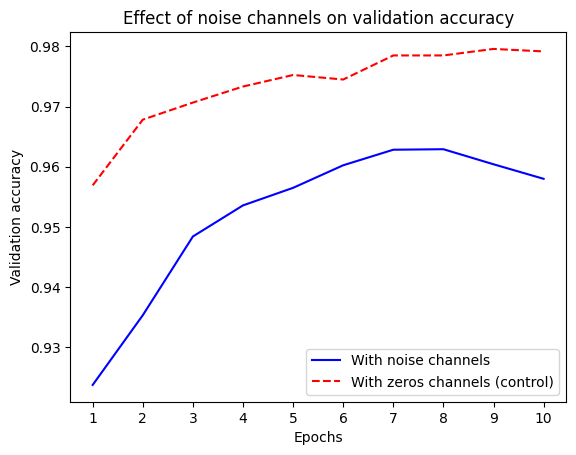

In [4]:
epochs = range(1, 11)
plt.plot(epochs, history_noise.history["val_accuracy"], "b-",
         label="With noise channels")
plt.plot(epochs, history_zeros.history["val_accuracy"], "r--",
         label="With zeros channels (control)")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

---
## Demo 2 — Model size and overfitting (IMDB)

Train a baseline model and a much larger model on IMDB sentiment classification.  
The bigger model overfits dramatically.

In [5]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/Users/ronaldlegere/Documents/dataSciDev/deep-learning-with-python-notebooks/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [6]:
# Baseline: 16-unit layers
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_original = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7774 - loss: 0.5364 - val_accuracy: 0.8552 - val_loss: 0.4112
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8896 - loss: 0.3336 - val_accuracy: 0.8845 - val_loss: 0.3146
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9120 - loss: 0.2517 - val_accuracy: 0.8869 - val_loss: 0.2900
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9289 - loss: 0.2061 - val_accuracy: 0.8910 - val_loss: 0.2742
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9429 - loss: 0.1703 - val_accuracy: 0.8853 - val_loss: 0.2864
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9525 - loss: 0.1433 - val_accuracy: 0.8878 - val_loss: 0.2856
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9581 - loss: 0.1261 - val_accuracy: 0.8815 - val_loss: 0.3086
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9659 - loss: 0.1071 - val_accuracy: 0.8854 - val_loss

In [7]:
# Much larger: 512-unit layers
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_larger = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7081 - loss: 0.5764 - val_accuracy: 0.8679 - val_loss: 0.3494
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8729 - loss: 0.3106 - val_accuracy: 0.8505 - val_loss: 0.3448
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9037 - loss: 0.2396 - val_accuracy: 0.8878 - val_loss: 0.2714
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9276 - loss: 0.1870 - val_accuracy: 0.8357 - val_loss: 0.4101
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9484 - loss: 0.1387 - val_accuracy: 0.8285 - val_loss: 0.5078
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9616 - loss: 0.1045 - val_accuracy: 0.8845 - val_loss: 0.3450
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9719 - loss: 0.0892 - val_accuracy: 0.8845 - val_loss: 0.3601
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9777 - loss: 0.0732 - val_accuracy: 0.8840 - v

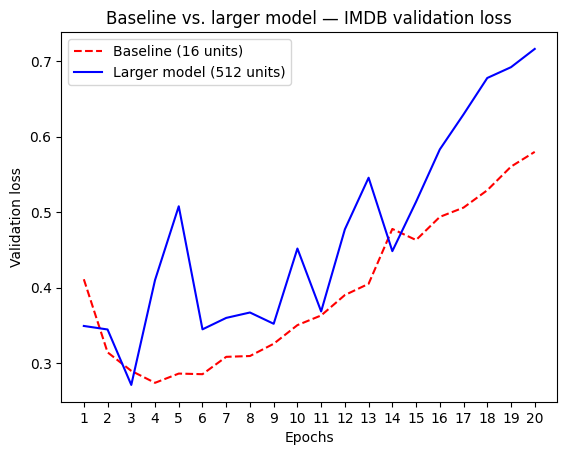

In [8]:
epochs = range(1, 21)
plt.plot(epochs, history_original.history["val_loss"], "r--",
         label="Baseline (16 units)")
plt.plot(epochs, history_larger.history["val_loss"], "b-",
         label="Larger model (512 units)")
plt.title("Baseline vs. larger model — IMDB validation loss")
plt.xlabel("Epochs")
plt.ylabel("Validation loss")
plt.xticks(epochs)
plt.legend()
plt.show()

---
## Demo 3 — Dropout fixes it


In [16]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.8),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.8),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6619 - loss: 0.6038 - val_accuracy: 0.8567 - val_loss: 0.3937
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8260 - loss: 0.4027 - val_accuracy: 0.8713 - val_loss: 0.3163
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8753 - loss: 0.3081 - val_accuracy: 0.8877 - val_loss: 0.2799
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9021 - loss: 0.2560 - val_accuracy: 0.8823 - val_loss: 0.2903
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9125 - loss: 0.2216 - val_accuracy: 0.8931 - val_loss: 0.2769
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9273 - loss: 0.1947 - val_accuracy: 0.8885 - val_loss: 0.3047
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9373 - loss: 0.1700 - val_accuracy: 0.8911 - val_loss: 0.3047
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9483 - loss: 0.1433 - val_accuracy: 0.8912 - v

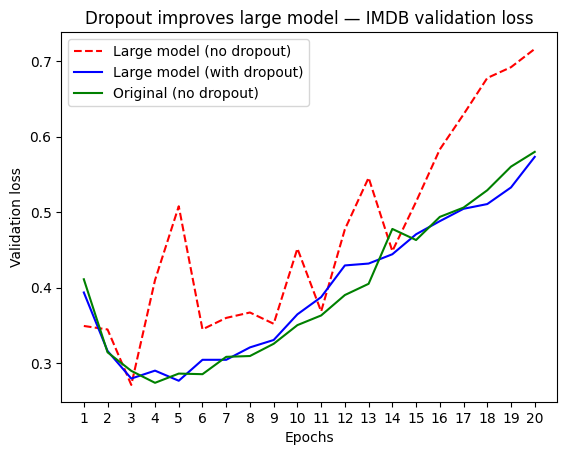

In [19]:
epochs = range(1, 21)
plt.plot(epochs, history_larger.history["val_loss"], "r--",
         label="Large model (no dropout)")
plt.plot(epochs, history_dropout.history["val_loss"], "b-",
         label="Large model (with dropout)")
plt.plot(epochs, history_original.history["val_loss"], "g-",
         label="Original (no dropout)")
plt.title("Dropout improves large model — IMDB validation loss")
plt.xlabel("Epochs")
plt.ylabel("Validation loss")
plt.xticks(epochs)
plt.legend()
plt.show()